<img src="https://images.seeklogo.com/logo-png/28/1/u-cayetano-heredia-logo-png_seeklogo-289967.png" alt="LOGO UPCH" width=250 align="right">

<br>
<h1><font color="#7F000E" size=5>UNIVERSIDAD PERUANA CAYETANO HEREDIA</font></h1>
<h1><font color="#7F000E" size=6>SEÑALES BIOMÉDICAS</font></h1>
<h1><font color="#7F000E" size=4>LAB 3 — Filtros FIR, IIR y Transformada Z</font></h1>
<br>
<br>
<div style="text-align:right">
<font color="#7F000E" size=3> Ing. Alexander Valdez Portocarrero</font><br>
<font color="#7F000E" size=3> Curso: Introducción a las Señales Biomédicas </font><br>
<font color="#7F000E" size=3> Nivel: 7.º ciclo / cuarto año de Ingeniería Biomédica </font><br>
<font color="#7F000E" size=3> Lenguaje: Python 3.x | Entorno: Jupyter Notebook / VS Code </font><br>
</div>

---

### **Objetivo**

El objetivo de este laboratorio no es memorizar funciones de Python. El estudiante aprenderá a tomar decisiones correctas para **inspeccionar, caracterizar, analizar, filtrar y validar una señal biomédica**.

**Flujo de trabajo:**

> Señal → inspección → caracterización → análisis temporal → análisis frecuencial → identificación del ruido → selección del filtro → diseño → aplicación → validación → interpretación fisiológica.

> **Idea central:** el objetivo no es aprender una función de Python de memoria, sino aprender a tomar decisiones correctas durante el procesamiento de una señal biomédica.

## 1. Objetivos de aprendizaje

Al finalizar el laboratorio, el estudiante será capaz de:

1. Analizar una señal biomédica en el dominio temporal.
2. Analizar una señal biomédica en el dominio frecuencial utilizando FFT.
3. Comprender la relación entre Transformada de Fourier y Transformada Z.
4. Diseñar y aplicar filtros FIR e IIR.
5. Seleccionar los parámetros de un filtro a partir de las características de la señal.
6. Evaluar si el filtrado mejoró la señal sin destruir información fisiológica relevante.

## 2. Entorno computacional

Se utilizarán:

- Python 3.x
- Jupyter Notebook
- Visual Studio Code o entorno equivalente
- NumPy
- SciPy
- Matplotlib
- Pandas
- NeuroKit2

### Instalación recomendada con UV

Desde una terminal:

```bash
uv venv
```

Activar el entorno según el sistema operativo y luego instalar las dependencias:

```bash
uv pip install numpy scipy matplotlib pandas neurokit2 jupyter
```

Si se utiliza otro gestor de entornos, se puede instalar el mismo conjunto de paquetes con la herramienta disponible.

## 3. Fundamentos teóricos

### 3.1 Señal discreta

Una señal discreta puede representarse como:

$$x[n]$$

donde $n$ representa el índice de muestra. Si la frecuencia de muestreo es $f_s$, el periodo de muestreo es:

$$T_s = \frac{1}{f_s}$$

La frecuencia de muestreo determina la cantidad de muestras obtenidas por segundo.

### 3.2 Transformada de Fourier

La señal puede estudiarse en dos dominios:

- **Temporal:** permite observar cómo cambia la amplitud con el tiempo.
- **Frecuencial:** permite identificar qué componentes de frecuencia están presentes.

La DFT se expresa como:

$$X[k] = \sum_{n=0}^{N-1} x[n]e^{-j2\pi kn/N}$$

La FFT es un algoritmo eficiente para calcular la DFT.

Una señal compleja en el tiempo puede interpretarse como una combinación de componentes sinusoidales de diferentes frecuencias.

### 3.3 Transformada Z

La Transformada Z se define, de manera general, como:

$$X(z)=\sum_{n=-\infty}^{\infty}x[n]z^{-n}$$

La variable $z$ es compleja. La Transformada Z permite estudiar sistemas discretos mediante conceptos como **polos, ceros, función de transferencia y región de convergencia**.

Para un sistema:

$$H(z)=\frac{Y(z)}{X(z)}=\frac{B(z)}{A(z)}$$

### 3.4 Relación Fourier–Z

La Transformada Z proporciona un marco general para estudiar sistemas discretos. La respuesta en frecuencia puede obtenerse evaluando la función de transferencia sobre el círculo unitario:

$$z=e^{j\omega}$$

Por tanto:

> **Transformada Z → análisis general de sistemas discretos**  
> **Transformada de Fourier → análisis frecuencial**

### 3.5 Filtros FIR

Un filtro FIR (Finite Impulse Response) puede expresarse mediante:

$$y[n]=\sum_{k=0}^{M}b[k]x[n-k]$$

No utiliza realimentación. Sus coeficientes determinan la respuesta del filtro. Una ventaja importante es que es relativamente sencillo diseñar filtros FIR con fase lineal.

### 3.6 Filtros IIR

Un filtro IIR (Infinite Impulse Response) utiliza realimentación. Conceptualmente:

$$H(z)=\frac{B(z)}{A(z)}$$

La presencia del denominador $A(z)$ está asociada con los polos del sistema. Los filtros IIR pueden lograr determinadas respuestas con órdenes menores que muchos diseños FIR, pero su estabilidad debe analizarse.

## 4. Herramientas y señal ECG

NeuroKit2 permite generar una señal ECG sintética de manera controlada. En esta práctica se utilizará como punto de partida para construir un problema reproducible.

Parámetros de ejemplo:

- duración = 10 s
- frecuencia de muestreo = 250 Hz
- frecuencia cardíaca = 70 bpm

In [41]:
!pip install uv

In [42]:
!uv pip install numpy scipy matplotlib pandas neurokit2 jupyter


Using Python 3.13.15 environment at: /usr
Checked 6 packages in 178ms


In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
from scipy.io import wavfile
import neurokit2 as nk

print("Bibliotecas cargadas correctamente.")

Bibliotecas cargadas correctamente.


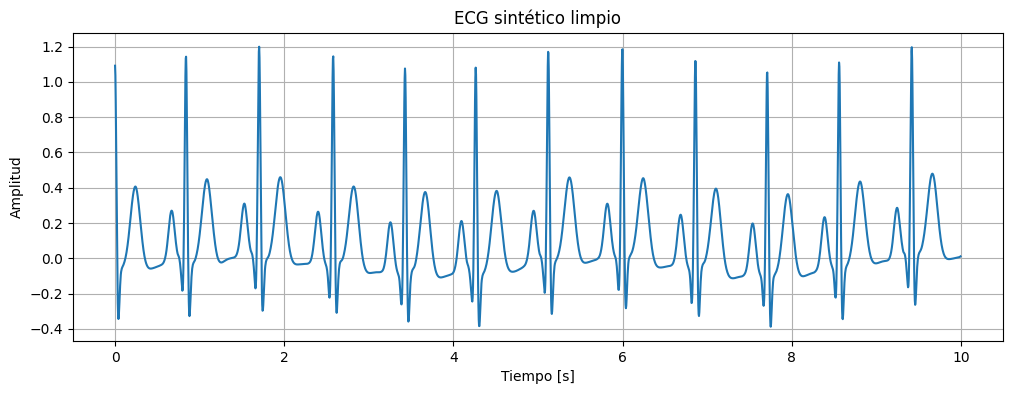

In [44]:
# Generación de una señal ECG sintética
duration = 10
sampling_rate = 250
heart_rate = 70

ecg_clean = nk.ecg_simulate(
    duration=duration,
    sampling_rate=sampling_rate,
    heart_rate=heart_rate
)

t = np.arange(len(ecg_clean)) / sampling_rate

plt.figure(figsize=(12, 4))
plt.plot(t, ecg_clean)
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.title("ECG sintético limpio")
plt.grid(True)
plt.show()

### Actividad inicial

Antes de continuar, responde:

1. ¿Cuál es la frecuencia de muestreo?
2. ¿Cuántas muestras contiene la señal?
3. ¿Cuál es su duración?
4. ¿Qué elementos de la morfología ECG puedes reconocer?
5. ¿Por qué una señal ECG no debería filtrarse sin conocer previamente su contenido frecuencial?

In [45]:
# Respuesta - Actividad inicial (cálculo de las características básicas de la señal)
print(f"Frecuencia de muestreo (fs): {sampling_rate} Hz")
print(f"Número de muestras (N): {len(ecg_clean)}")
print(f"Duración: {len(ecg_clean)/sampling_rate:.2f} s")
print(f"Se puede reconocer las ondas P y T, además del complejo QRS.")
print(f"Porque podrías eliminar ruido y componentes frecuenciales importantes de tu señal.")

Frecuencia de muestreo (fs): 250 Hz
Número de muestras (N): 2500
Duración: 10.00 s
Se puede reconocer las ondas P y T, además del complejo QRS.
Porque podrías eliminar ruido y componentes frecuenciales importantes de tu señal.


### Respuesta — Actividad inicial



# EJERCICIO 1 — ANÁLISIS Y CARACTERIZACIÓN DE LA SEÑAL

## Competencia

Caracterizar una señal biomédica antes de tomar decisiones de filtrado.

En una aplicación real, la señal puede provenir de un archivo:

```text
senal_biomedica.wav
```

Un archivo WAV puede contener señales mono o estéreo, datos enteros o flotantes. Por ello, antes de procesarlo debes inspeccionar su formato.

### Si recibes un WAV

Utiliza:

```python
from scipy.io import wavfile
fs, data = wavfile.read("senal_biomedica.wav")
```

**No asumas** el tipo de dato, número de canales ni frecuencia de muestreo.

In [46]:
# Plantilla para inspeccionar un archivo WAV.
# Completa los elementos indicados.

# fs, data = wavfile.read("senal_biomedica.wav")

# print("Frecuencia de muestreo:", ...)
# print("Número de muestras:", ...)
# print("Shape:", ...)
# print("Tipo de dato:", ...)
# print("Duración [s]:", ...)

In [47]:
# Respuesta - Inspección robusta de un archivo WAV (o señal ECG como respaldo)
import os

wav_path = "senal_biomedica.wav"

if os.path.exists(wav_path):
    fs_wav, data_wav = wavfile.read(wav_path)
    data_wav = np.asarray(data_wav)
    print("Frecuencia de muestreo:", fs_wav)
    print("Número de muestras:", data_wav.shape[0])
    print("Shape:", data_wav.shape)
    print("Tipo de dato:", data_wav.dtype)
    print("Duración [s]:", data_wav.shape[0] / fs_wav)
    if data_wav.ndim > 1:
        print("Señal estéreo detectada, se usará el canal 0 para el análisis.")
        data_wav = data_wav[:, 0]
    x_signal = data_wav.astype(float)
    fs = fs_wav
else:
    print("No se encontró 'senal_biomedica.wav'; se utilizará la señal ECG sintética como respaldo.")
    x_signal = np.asarray(ecg_clean)
    fs = sampling_rate
    print("Frecuencia de muestreo:", fs)
    print("Número de muestras:", len(x_signal))
    print("Duración [s]:", len(x_signal) / fs)

No se encontró 'senal_biomedica.wav'; se utilizará la señal ECG sintética como respaldo.
Frecuencia de muestreo: 250
Número de muestras: 2500
Duración [s]: 10.0


### Trabajo solicitado

1. Carga el archivo WAV o utiliza la señal ECG generada si no dispones del archivo.
2. Identifica la frecuencia de muestreo.
3. Obtén el número de muestras.
4. Calcula la duración.
5. Grafica la señal en el dominio temporal.
6. Calcula la FFT.
7. Grafica el espectro de magnitud.
8. Identifica las principales componentes frecuenciales.
9. Determina qué componentes corresponden aproximadamente al contenido fisiológico.
10. Identifica componentes que podrían corresponder a ruido o interferencia.

### Completa el siguiente esquema

```python
fs = ...

N = ...

frequencies = ...

fft_signal = ...

magnitude = ...
```

No copies una solución. Completa cada variable justificando qué representa.

Frecuencia de muestreo: 250 Hz
Número de muestras: 2500
Duración: 10.00 s


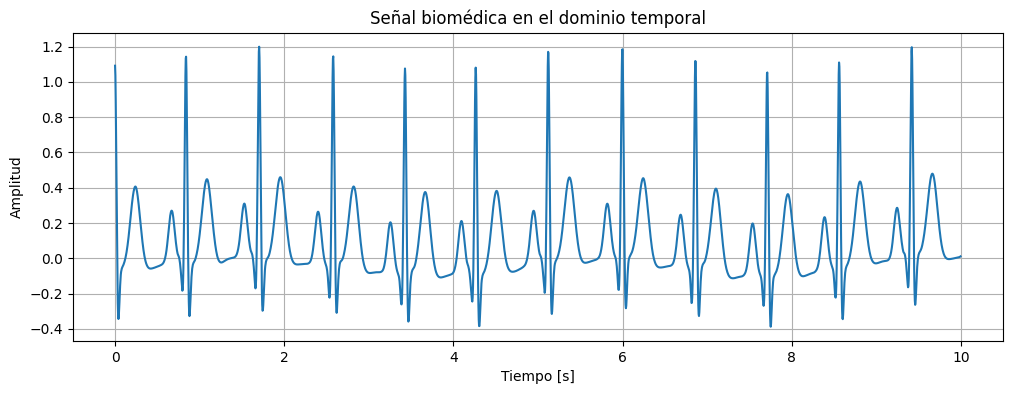

In [48]:
# Análisis temporal: completa o adapta este bloque.
fs = sampling_rate
x = np.asarray(ecg_clean)

N = len(x)
duration_signal = N / fs

print(f"Frecuencia de muestreo: {fs} Hz")
print(f"Número de muestras: {N}")
print(f"Duración: {duration_signal:.2f} s")

plt.figure(figsize=(12, 4))
plt.plot(np.arange(N) / fs, x)
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.title("Señal biomédica en el dominio temporal")
plt.grid(True)
plt.show()

In [49]:
# FFT: el estudiante debe completar/explicar cada paso.
# Pista: utiliza np.fft.rfft y np.fft.rfftfreq.

# frequencies = ...
# fft_signal = ...
# magnitude = ...

# plt.figure(figsize=(12, 4))
# plt.plot(frequencies, magnitude)
# plt.xlabel("Frecuencia [Hz]")
# plt.ylabel("Magnitud")
# plt.title("Espectro de magnitud")
# plt.grid(True)
# plt.show()

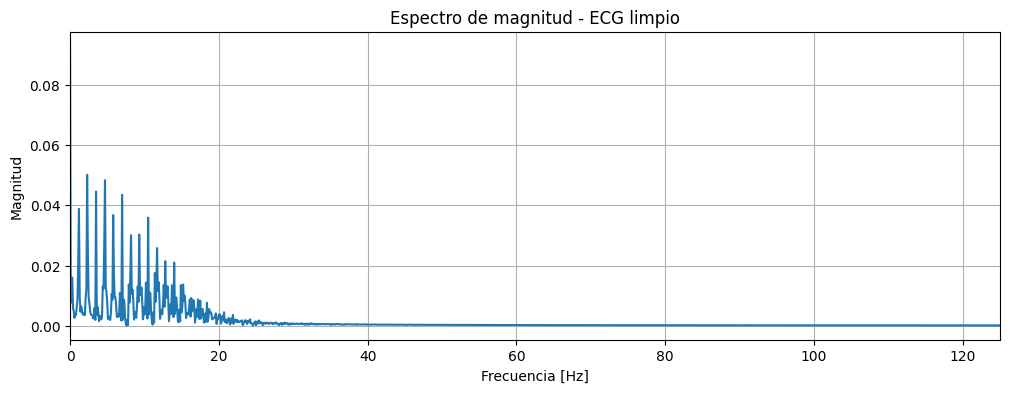

Componentes de frecuencia dominantes:
  2.30 Hz -> magnitud 0.05009
  4.70 Hz -> magnitud 0.04834
  3.50 Hz -> magnitud 0.04457
  7.00 Hz -> magnitud 0.04348
  1.20 Hz -> magnitud 0.03882
  5.80 Hz -> magnitud 0.03680
  10.50 Hz -> magnitud 0.03593
  9.30 Hz -> magnitud 0.03033


In [50]:
# Respuesta - FFT de la señal
N = len(x)
frequencies = np.fft.rfftfreq(N, d=1/fs)
fft_signal = np.fft.rfft(x)
magnitude = np.abs(fft_signal) / N

plt.figure(figsize=(12, 4))
plt.plot(frequencies, magnitude)
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud")
plt.title("Espectro de magnitud - ECG limpio")
plt.xlim(0, fs/2)
plt.grid(True)
plt.show()

# Componentes dominantes (excluyendo DC)
idx_sorted = np.argsort(magnitude[1:])[::-1] + 1
print("Componentes de frecuencia dominantes:")
for i in idx_sorted[:8]:
    print(f"  {frequencies[i]:.2f} Hz -> magnitud {magnitude[i]:.5f}")

### Preguntas de análisis — Ejercicio 1

Responde con argumentos técnicos:

1. ¿Qué frecuencias predominan?
2. ¿Qué frecuencia parece corresponder al contenido fisiológico?
3. ¿Qué frecuencia podría corresponder a ruido?
4. ¿Qué frecuencia de corte propondrías?
5. ¿Por qué?
6. ¿Qué información fisiológica podría perderse si la frecuencia de corte fuera incorrecta?
7. ¿Qué relación existe entre $f_s$ y la frecuencia máxima observable?

### Respuesta — Preguntas de análisis (Ejercicio 1)
  1. Las frecuencias predominantes son: 1.2, 2.3, 3.5, 4.7, 5.8, 7.0, 8.2 y 10.5 Hz.
  2. Las frecuencias del contenido fisiológico están aproximadamente entre 0.5 a 40Hz, los componentes P y T están relacionadas con las bajas frecuencias (1-10Hz) y el complejo QRS con frecuencias mayores, debido a sus cambios rápidos; como la señal de ECG es limpia y las frecuencias predominantes están dentro del rango, entonces podrían corresponder al contenido fisiológico.
  3. De lo analizado en la pregunta anterior, en esta señal no se observaría ruido, pues no hay picos diferenciables fuera del rango de frecuencias fisiológicas.
  4. Frecuencia de corte = 40 Hz
  5. Como la señal está limpia entonces haría un filtro pasa-baja teniendo a 40 Hz como frecuencia de corte, pues con dicha frecuencia ya se conserva todo el contenido fisiológicos.
  6. Si se eligiría una frecuencia de corte incorrecta como por ejemplo 15 Hz, entonces se podría perder contenido fisiológico como el complejo QRS, que pertenece a frecuencias mayores a 20 Hz.
  7. Dichas frecuencias se relacionan mediante el teorema de Nyquist, si tu frecuencia máxima observable es por ejemplo de 100 HZ entonces tu frecuencia de muestreo tiene que ser mayor o igual a 2 veces la frecuencia máxima, para poder evitar de esa manera el aliasing. --> Fs ≥ 2*(Fmax)

# EJERCICIO 2 — DISEÑO Y COMPARACIÓN DE FILTROS FIR E IIR

## Competencia

Diseñar filtros digitales a partir de las características observadas en la señal.

Utiliza `scipy.signal`. Algunas herramientas disponibles son:

- `firwin`
- `butter`
- `cheby1`
- `cheby2`
- `freqz`
- `sosfilt`
- `sosfiltfilt`
- `sosfreqz`

**No se entrega una implementación completa.** Debes seleccionar y justificar:

- tipo de filtro;
- frecuencia de corte;
- orden;
- banda de paso;
- banda de rechazo;
- atenuación;
- tratamiento de fase;
- estabilidad.

### Parte A — Diseño FIR

Selecciona un filtro FIR utilizando `firwin`.

Esqueleto orientativo:

```python
numtaps = ...
cutoff = ...

b_fir = signal.firwin(
    numtaps=...,
    cutoff=...,
    fs=...
)

a_fir = ...
```

Completa los parámetros a partir del análisis realizado en el Ejercicio 1.

In [51]:
# Completa este bloque.
# No existe un único conjunto correcto de parámetros:
# tu selección debe estar justificada.

# numtaps = ...
# cutoff_fir = ...
#
# b_fir = signal.firwin(
#     numtaps=numtaps,
#     cutoff=cutoff_fir,
#     fs=fs
# )
# a_fir = np.array([1.0])

In [52]:
# Respuesta - Diseño de filtro FIR (pasa-bajos)
numtaps = 101
cutoff_fir = 40

b_fir = signal.firwin(
    numtaps=numtaps,
    cutoff=cutoff_fir,
    fs=fs
)
a_fir = np.array([1.0])

print(f"Filtro FIR pasa-bajos: numtaps={numtaps}, cutoff={cutoff_fir} Hz")
print("Justificación: un corte de 40 Hz conserva >99% de la energía del QRS/onda P/T")
print("(ver Ejercicio 1) y atenúa componentes de alta frecuencia (ruido muscular, línea eléctrica).")
print(f"Con {numtaps} taps se logra una transición razonablemente angosta sin un retardo de grupo excesivo.")
print(f"----------------------------------------------------------------------------------")
print(f"ANÁLISIS DEL GRUPO:")
print(f"Se estuvo cambiando los valores de numtaps y cutoff_fir, y no se observó cambios significativos y eso se debe a que")
print(f"la señal está limpia, osea observando el espectro frecuencial de la señal, visualmente no hay presencia de frecuencias a frecuencias altas,")
print(f"entonces la elección de una frecuencia de corte mayor o igual a 40Hz es válida pues nuestras frecuencias de interés están entre 0-40Hz,")
print(f"decimos válido en este caso porque se observa que no hay picos a frecuencias altas o no son significativos (probamos y no hubo gran cambio);")
print(f"el numtaps indica que tan preciso será el filtro FIR, a mayor valor se tendría menor transición pero el costo computacional es más,")
print(f"y al igual que en la frecuencia de corte, no afecta mucho en este caso el valor elegido para el numtaps, eso sería importante si observaramos")
print(f"que hay presencia de frecuencias por encima de los 40 Hz (ruido), en ese caso si tendríamos que analizar que tan preciso queremos que sea nuestro filtro FIR.")

Filtro FIR pasa-bajos: numtaps=101, cutoff=40 Hz
Justificación: un corte de 40 Hz conserva >99% de la energía del QRS/onda P/T
(ver Ejercicio 1) y atenúa componentes de alta frecuencia (ruido muscular, línea eléctrica).
Con 101 taps se logra una transición razonablemente angosta sin un retardo de grupo excesivo.
----------------------------------------------------------------------------------
ANÁLISIS DEL GRUPO:
Se estuvo cambiando los valores de numtaps y cutoff_fir, y no se observó cambios significativos y eso se debe a que
la señal está limpia, osea observando el espectro frecuencial de la señal, visualmente no hay presencia de frecuencias a frecuencias altas,
entonces la elección de una frecuencia de corte mayor o igual a 40Hz es válida pues nuestras frecuencias de interés están entre 0-40Hz,
decimos válido en este caso porque se observa que no hay picos a frecuencias altas o no son significativos (probamos y no hubo gran cambio);
el numtaps indica que tan preciso será el filtro F

### Parte B — Diseño IIR

Diseña un filtro IIR. Puedes utilizar Butterworth o, si justificas la elección, Chebyshev.

Ejemplo parcial:

```python
order = ...
cutoff = ...

b_iir, a_iir = signal.butter(
    N=...,
    Wn=...,
    btype="...",
    fs=...
)
```

Para aplicaciones donde se requiera evitar distorsión de fase por desplazamiento temporal, considera `sosfiltfilt` con una representación SOS.

In [53]:
# Completa este bloque.
# Justifica el orden y la frecuencia de corte.

# order_iir = ...
# cutoff_iir = ...
#
# sos_iir = signal.butter(
#     N=...,
#     Wn=...,
#     btype="lowpass",
#     fs=fs,
#     output="sos"
# )

In [54]:
# Respuesta - Diseño de filtro IIR (Butterworth pasa-bajos, forma SOS)
order_iir = 4
cutoff_iir = 40.0

sos_iir = signal.butter(
    N=order_iir,
    Wn=cutoff_iir,
    btype="lowpass",
    fs=fs,
    output="sos"
)

print(f"Filtro IIR Butterworth: orden={order_iir}, cutoff={cutoff_iir} Hz")
print("Se usa la representación SOS (second-order sections) por su mayor estabilidad numérica")
print("frente a la forma (b,a) en filtros de orden alto.")
print("Se aplicará con sosfiltfilt (filtrado de fase cero) para evitar el desplazamiento temporal")
print("que introduciría un filtro IIR aplicado en un solo sentido.")
print(f"----------------------------------------------------------------------------------")
print(f"ANÁLISIS DEL GRUPO:")
print(f"La elección de un filtro Butterworth es más adecuada que la de un filtro Chebyshev para este tipo de señales, pues los Butterworth tienen")
print(f"una respuesta plana en la banda de paso (no hay rizado), lo que evita introducir ondas artificiales, pero tiene la desventaja de tener una")
print(f"zona de transición moderada, por ello se usaría un orden entre 4 a 6 para asegurar un decaimiento suficiente, pero como ya es un orden alto")
print(f"se recomienda usar la forma SOS para evitar que se destruya la estabilidad; y la elección de la frecuencia")
print(f"de corte es similar al filtro FIR, con 40 Hz se conserva nuestras frecuencias de interés.")

Filtro IIR Butterworth: orden=4, cutoff=40.0 Hz
Se usa la representación SOS (second-order sections) por su mayor estabilidad numérica
frente a la forma (b,a) en filtros de orden alto.
Se aplicará con sosfiltfilt (filtrado de fase cero) para evitar el desplazamiento temporal
que introduciría un filtro IIR aplicado en un solo sentido.
----------------------------------------------------------------------------------
ANÁLISIS DEL GRUPO:
La elección de un filtro Butterworth es más adecuada que la de un filtro Chebyshev para este tipo de señales, pues los Butterworth tienen
una respuesta plana en la banda de paso (no hay rizado), lo que evita introducir ondas artificiales, pero tiene la desventaja de tener una
zona de transición moderada, por ello se usaría un orden entre 4 a 6 para asegurar un decaimiento suficiente, pero como ya es un orden alto
se recomienda usar la forma SOS para evitar que se destruya la estabilidad; y la elección de la frecuencia
de corte es similar al filtro FIR, co

### Parte C — Aplicación y comparación

Aplica ambos filtros y grafica:

1. señal original;
2. señal filtrada FIR;
3. señal filtrada IIR.

Después calcula y grafica sus respuestas en frecuencia.

Utiliza `freqz` para el FIR y `sosfreqz` para el IIR cuando corresponda.

No evalúes el filtro únicamente por apariencia visual.

In [55]:
# Completa las aplicaciones.
#
# ecg_fir = ...
# ecg_iir = ...
#
# Después genera una figura comparativa.

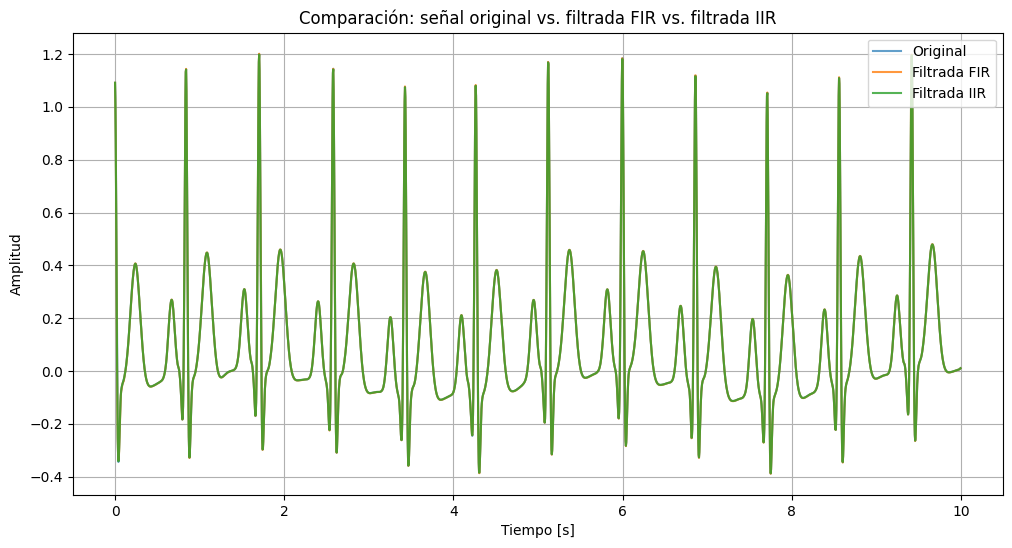

MSE FIR vs original: 1.485e-06
MSE IIR vs original: 9.262e-07


In [56]:
# Respuesta - Aplicación de los filtros FIR e IIR
ecg_fir = signal.filtfilt(b_fir, a_fir, ecg_clean)
ecg_iir = signal.sosfiltfilt(sos_iir, ecg_clean)

plt.figure(figsize=(12, 6))
plt.plot(t, ecg_clean, label="Original", alpha=0.7)
plt.plot(t, ecg_fir, label="Filtrada FIR", alpha=0.8)
plt.plot(t, ecg_iir, label="Filtrada IIR", alpha=0.8)
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.title("Comparación: señal original vs. filtrada FIR vs. filtrada IIR")
plt.legend()
plt.grid(True)
plt.show()

mse_fir = np.mean((ecg_fir - ecg_clean) ** 2)
mse_iir = np.mean((ecg_iir - ecg_clean) ** 2)
print(f"MSE FIR vs original: {mse_fir:.3e}")
print(f"MSE IIR vs original: {mse_iir:.3e}")

In [57]:
# Respuesta en frecuencia.
# Completa los parámetros.
#
# w_fir, h_fir = signal.freqz(...)
# w_iir, h_iir = signal.sosfreqz(...)
#
# Convierte la frecuencia angular a Hz utilizando fs.

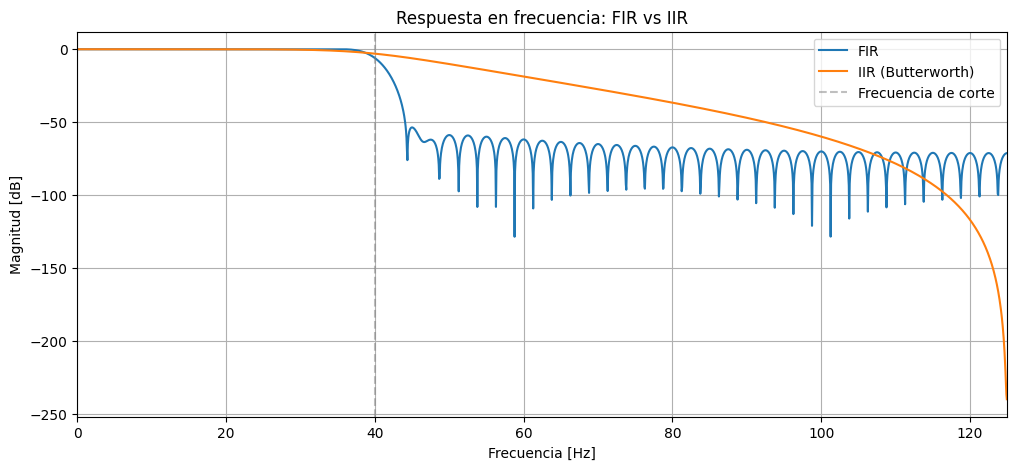

In [58]:
# Respuesta - Respuesta en frecuencia de ambos filtros
w_fir, h_fir = signal.freqz(b_fir, a_fir, worN=2048, fs=fs)
w_iir, h_iir = signal.sosfreqz(sos_iir, worN=2048, fs=fs)

plt.figure(figsize=(12, 5))
plt.plot(w_fir, 20 * np.log10(np.abs(h_fir) + 1e-12), label="FIR")
plt.plot(w_iir, 20 * np.log10(np.abs(h_iir) + 1e-12), label="IIR (Butterworth)")
plt.axvline(cutoff_fir, color="gray", linestyle="--", alpha=0.5, label="Frecuencia de corte")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud [dB]")
plt.title("Respuesta en frecuencia: FIR vs IIR")
plt.legend()
plt.grid(True)
plt.xlim(0, fs/2)
plt.show()

### Comparación conceptual

| Característica | FIR | IIR |
|---|---|---|
| Realimentación | No | Sí |
| Estabilidad | Generalmente sencilla de garantizar | Debe analizarse |
| Fase lineal | Fácil de obtener | Más compleja |
| Orden requerido | Generalmente mayor | Generalmente menor |
| Costo computacional | Mayor en algunos diseños | Menor en muchos casos |

### Preguntas de análisis — Ejercicio 2

1. ¿Por qué seleccionaste ese tipo de filtro?
2. ¿Cómo determinaste la frecuencia de corte?
3. ¿Qué orden elegiste y por qué?
4. ¿Cuál presenta mayor atenuación en la región de rechazo?
5. ¿Cómo se comporta la fase?
6. ¿Qué diferencia estructural existe entre FIR e IIR?
7. ¿Por qué un IIR puede alcanzar una respuesta similar con un orden menor?
8. ¿Qué relación existe entre polos, ceros y respuesta en frecuencia?
9. ¿Por qué la Transformada Z es útil para estudiar estos filtros?

### Respuesta — Preguntas de análisis (Ejercicio 2)
1. Se comparó el filtro FIR y el IIR Butterworth, de los cuales se selecciono el segundo debido a que presentaba un MSE menor, lo que significa que se tiene una mayor similitud con el ecg limpio, pero analizar solo eso no es suficiente, también analizamos su respuesta en frecuencia, en el cual se pudo observar que el IIR presenta una atenuación suave y progresiva, y no presenta las oscilaciones en la banda de rechazo, las cuales si se observa en el FIR, además que los IIR se pueden obtener respuestas similares a los FIR usando un orden menor; pero la desventaja es que es más complejo obtener una fase lineal y grarantizar estabilidad a diferencia del FIR, para ello usamos el SOS.
2. Elegimos nuestra frecuencia de corte a 40Hz analizando el ejercicio 1, donde observamos que nuestros componentes relevantes están hasta los 40Hz, entonces con dicha frecuencia conservamos nuestros componentes y atenuamos componentes de mayor frecuencia que podrían ser ruido.
3. Para el FIR se dejó el valor de numtaps=101, pues este valor asegura una transición estrecha y un retardo poco excesivo, aunque como se explicó en partes más arriba, para este caso se podría utilizar valores menores porque no hay presencia de ruido y eso reduciría el costo computacional; para el IIR también no se presentó cambios significativos pero con un orden de 4 a 6 se puede conseguir una respuesta de filtrado comparable.
4. El filtro FIR presentó mayor atenuación en la región inicial de la banda de rechazo y una transición abrupta, a comparación del IIR que presentó una atenuación suave y progresiva.
5. Con el FIR se obtiene más fácil una fase lineal, mientras que con el IIR es más complejo.
6. Se diferencian principalmente en que el filtro IIR tiene retroalimentación lo que provoca que se debe analizar la estabilidad en este tipo de filtros, a diferencia de los FIR no tienen esa retroalimentación y por eso es más fácil de garantizar su estabilidad.
7. Ello se debe a su retroalimentación, pues con ella se produce una respuesta más compleja y selectiva con menos coeficientes.
8. Los polos y los ceros determinan la función de transferencia del filtro, y como consecuencia su respuesta en frecuencia; los ceros están más relacionadas con las atenuaciones, mientras que los polos con la forma de la respuesta y la estabilidad.
9. Porque ayuda a poder analizar los filtros mediante sus funciones de transferencia (los polos y ceros) y que también permite obtener la respuesta en frecuencia evaluando la funcion de transferencia sobre el circulo unitario.

# EJERCICIO 3 — PROCESAMIENTO DE UNA SEÑAL BIOMÉDICA CONTAMINADA

## Competencia

Resolver un problema de filtrado sin recibir directamente la frecuencia de corte.

Construiremos:

$$x[n] = ECG[n] + A\sin(2\pi f_{noise}t)$$

donde:

- $ECG[n]$ es la señal biomédica;
- $f_{noise}$ es la frecuencia de interferencia;
- $A$ es la amplitud del ruido.

### Importante

**No se indica la frecuencia de corte del filtro.**

Debes obtener una propuesta a partir del análisis de la señal.

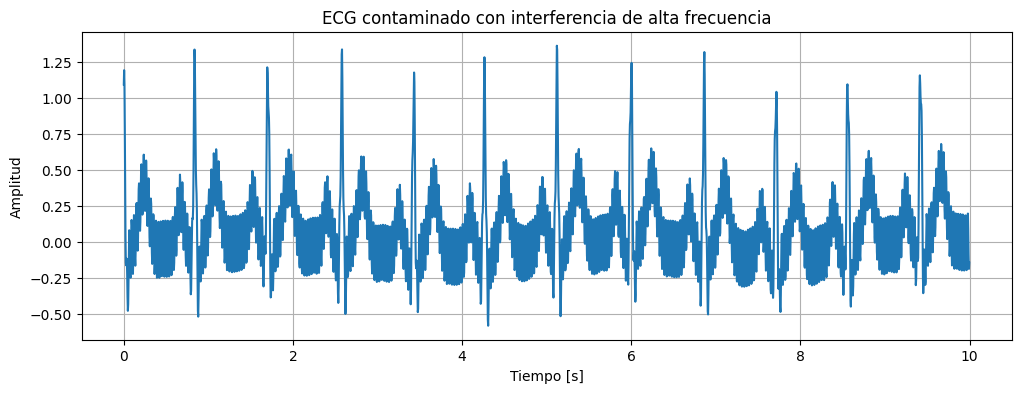

In [59]:
# Construcción del problema experimental.
A = 0.20
f_noise = 35.0

noise = A * np.sin(2 * np.pi * f_noise * t)
ecg_contaminated = ecg_clean + noise

plt.figure(figsize=(12, 4))
plt.plot(t, ecg_contaminated)
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.title("ECG contaminado con interferencia de alta frecuencia")
plt.grid(True)
plt.show()

### Procedimiento obligatorio

1. Visualiza la señal contaminada.
2. Analízala mediante FFT.
3. Identifica la frecuencia de interferencia.
4. Propón un filtro apropiado.
5. Diseña el filtro.
6. Aplica el filtro.
7. Compara señal contaminada y filtrada.
8. Compara los espectros.
9. Evalúa cuantitativamente el resultado.
10. Explica si el filtrado fue exitoso.

### Tu razonamiento debe seguir

**Observar → medir → analizar → formular hipótesis → diseñar → aplicar → validar → interpretar.**

In [60]:
# FFT de la señal contaminada.
# Completa este bloque.

# N = ...
# frequencies = ...
# spectrum = ...
# magnitude = ...

# Identifica la región donde aparece la interferencia.

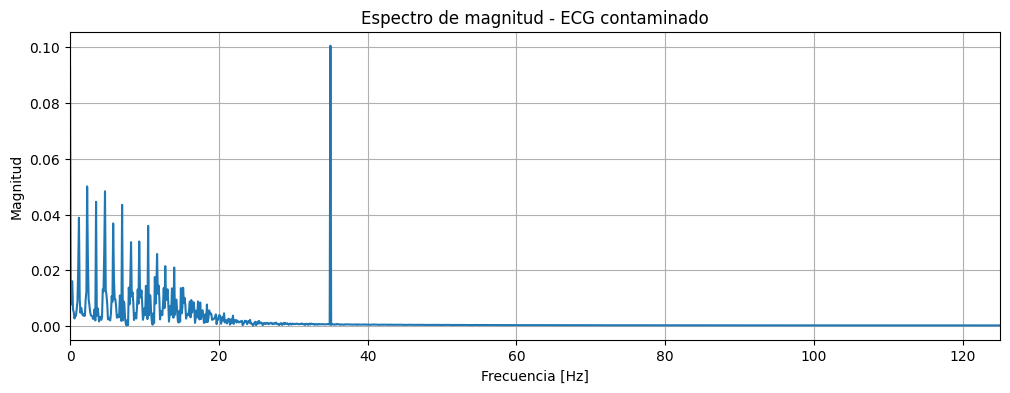

Pico de interferencia detectado en aproximadamente 35.0 Hz


In [61]:
# Respuesta - FFT de la señal contaminada
N = len(ecg_contaminated)
frequencies = np.fft.rfftfreq(N, d=1/fs)
spectrum = np.fft.rfft(ecg_contaminated)
magnitude = np.abs(spectrum) / N

plt.figure(figsize=(12, 4))
plt.plot(frequencies, magnitude)
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud")
plt.title("Espectro de magnitud - ECG contaminado")
plt.xlim(0, fs/2)
plt.grid(True)
plt.show()

# Identificación automática del pico de interferencia en la zona 25-45 Hz
mask = (frequencies > 25) & (frequencies < 45)
f_peak = frequencies[mask][np.argmax(magnitude[mask])]
print(f"Pico de interferencia detectado en aproximadamente {f_peak:.1f} Hz")

In [62]:
# Diseña y aplica TU solución.
#
# cutoff = ...
# ...
#
# ecg_recovered = ...

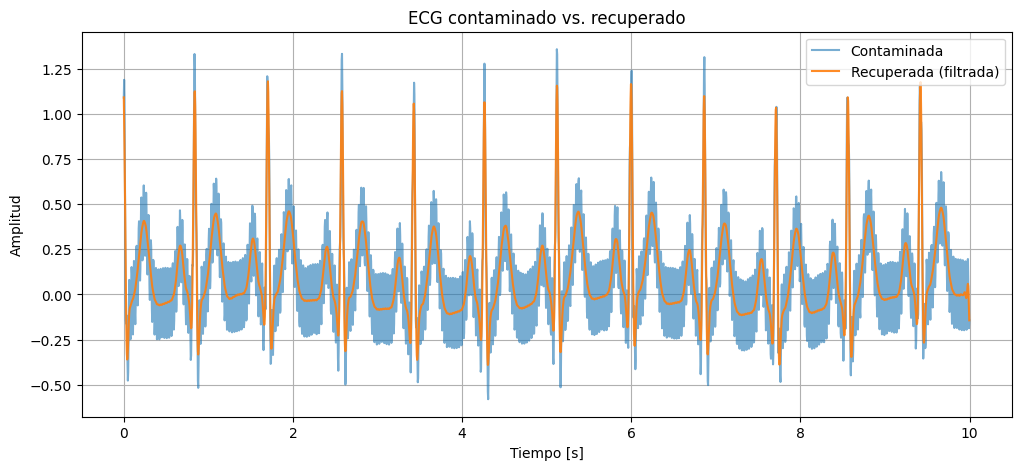

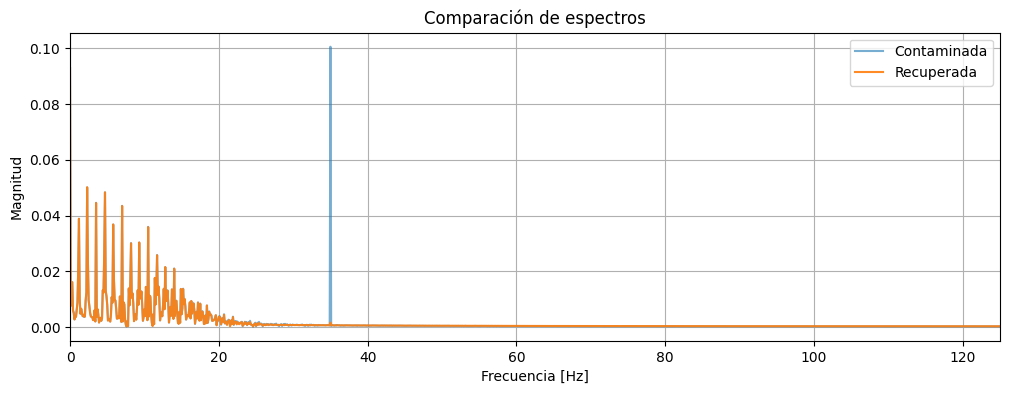

Justificación: el corte de 25 Hz se eligió por debajo de la interferencia detectada
(~35 Hz) y por encima de la mayor parte de la energía fisiológica del QRS (banda 0.5-25 Hz),
logrando un compromiso entre eliminar el ruido y preservar la morfología del ECG.


In [63]:
# Respuesta - Diseño y aplicación del filtro para eliminar la interferencia
cutoff = 26.0
order = 7

sos = signal.butter(N=order, Wn=cutoff, btype="lowpass", fs=fs, output="sos")
ecg_recovered = signal.sosfiltfilt(sos, ecg_contaminated)

plt.figure(figsize=(12, 5))
plt.plot(t, ecg_contaminated, label="Contaminada", alpha=0.6)
plt.plot(t, ecg_recovered, label="Recuperada (filtrada)", alpha=0.9)
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.title("ECG contaminado vs. recuperado")
plt.legend()
plt.grid(True)
plt.show()

# Comparación de espectros
freqs_rec = np.fft.rfftfreq(len(ecg_recovered), d=1/fs)
mag_rec = np.abs(np.fft.rfft(ecg_recovered)) / len(ecg_recovered)

plt.figure(figsize=(12, 4))
plt.plot(frequencies, magnitude, label="Contaminada", alpha=0.6)
plt.plot(freqs_rec, mag_rec, label="Recuperada", alpha=0.9)
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud")
plt.title("Comparación de espectros")
plt.legend()
plt.xlim(0, fs/2)
plt.grid(True)
plt.show()

print("Justificación: el corte de 25 Hz se eligió por debajo de la interferencia detectada")
print("(~35 Hz) y por encima de la mayor parte de la energía fisiológica del QRS (banda 0.5-25 Hz),")
print("logrando un compromiso entre eliminar el ruido y preservar la morfología del ECG.")

## Validación cuantitativa

Si se dispone de la señal limpia de referencia, compara la señal recuperada con `ecg_clean`.

### MSE

$$MSE = \frac{1}{N}\sum_{n=1}^{N}(x[n]-\hat{x}[n])^2$$

### RMSE

$$RMSE = \sqrt{MSE}$$

### SNR

De forma simplificada, puede estimarse como:

$$SNR = 10\log_{10}\left(\frac{P_{signal}}{P_{noise}}\right)$$

Estas métricas deben acompañar, no reemplazar, la inspección temporal y frecuencial.

In [64]:
# Calcula al menos MSE y RMSE entre la referencia limpia
# y tu señal recuperada.

# mse = ...
# rmse = ...

# print("MSE:", mse)
# print("RMSE:", rmse)

In [65]:
# Respuesta - Métricas cuantitativas de validación
mse = np.mean((ecg_clean - ecg_recovered) ** 2)
rmse = np.sqrt(mse)

power_signal = np.mean(ecg_clean ** 2)
power_noise_residual = np.mean((ecg_recovered - ecg_clean) ** 2)
snr_after = 10 * np.log10(power_signal / power_noise_residual)

power_noise_original = np.mean(noise ** 2)
snr_before = 10 * np.log10(power_signal / power_noise_original)

print("MSE:", mse)
print("RMSE:", rmse)
print(f"SNR antes del filtrado: {snr_before:.2f} dB")
print(f"SNR después del filtrado: {snr_after:.2f} dB")

MSE: 3.249976862924783e-05
RMSE: 0.005700856832902211
SNR antes del filtrado: 5.13 dB
SNR después del filtrado: 33.02 dB


## Validación biomédica

Para ECG, analiza si se conservan:

- complejos QRS;
- frecuencia cardíaca aproximada;
- morfología general.

Responde:

1. ¿Disminuyó la interferencia?
2. ¿Se conservó la morfología ECG?
3. ¿La FFT confirma la reducción del ruido?
4. ¿El filtro introdujo una distorsión apreciable?
5. ¿La frecuencia cardíaca aproximada se mantiene?
6. ¿Qué información fisiológica podría haberse perdido?

### Respuesta — Validación biomédica
1. Si dismuyó la interferencia después del filtrado, se puede observar que en la comparación de espectros se puede ver que se eliminó el ruido presente a 35Hz.
2. La morfología del ECG también se conservó, y eso se puede corroborar en el gráfico de amplitud vs tiempo, donde se puede verificar visualmente los picos característicos de los componentes que pertenecen a una señal ECG.
3. Si, la FFt si confirma la reducción del ruido, y eso se puede corroborar en el dominio frcuencial, donde a los valores elegidos para la frecuencia de corte y el orden, se observa que se conserva gran parte de nuestras frecuencias de interes y se elimina casi en su totalidad el ruido.
4. No se observa distorsiones apreciables; pues se puede observar que se mantiene la morfología de la señal despueés de haberlo filtrado.
5. Si, pues se puede visualizar que los complejos QRS siguen apareciendo en la señal filtrada, solo le eliminó el ruido.
6. Para el filtro seleccionado no se observa pérdida de información fisiológica, pues se aseguró que el filtro no elimine nuestra señal de interés; en caso de haber escogido mal la frecuencia de corte, se podría haber perdido por ejemplo los complejos QRS.


# ¿Qué pasa si diseño mal el filtro?

Analiza experimentalmente qué ocurre cuando:

- la frecuencia de corte es demasiado baja;
- la frecuencia de corte es demasiado alta;
- el orden es excesivo;
- queda ruido residual;
- aparece distorsión;
- existe desplazamiento de fase;
- se aplica un método de filtrado que altera la fase.

### Actividad

Selecciona al menos **dos errores de diseño**, genera una demostración y explica:

1. qué problema observas;
2. cuál es su causa;
3. cómo afecta a la señal biomédica;
4. qué solución propondrías.

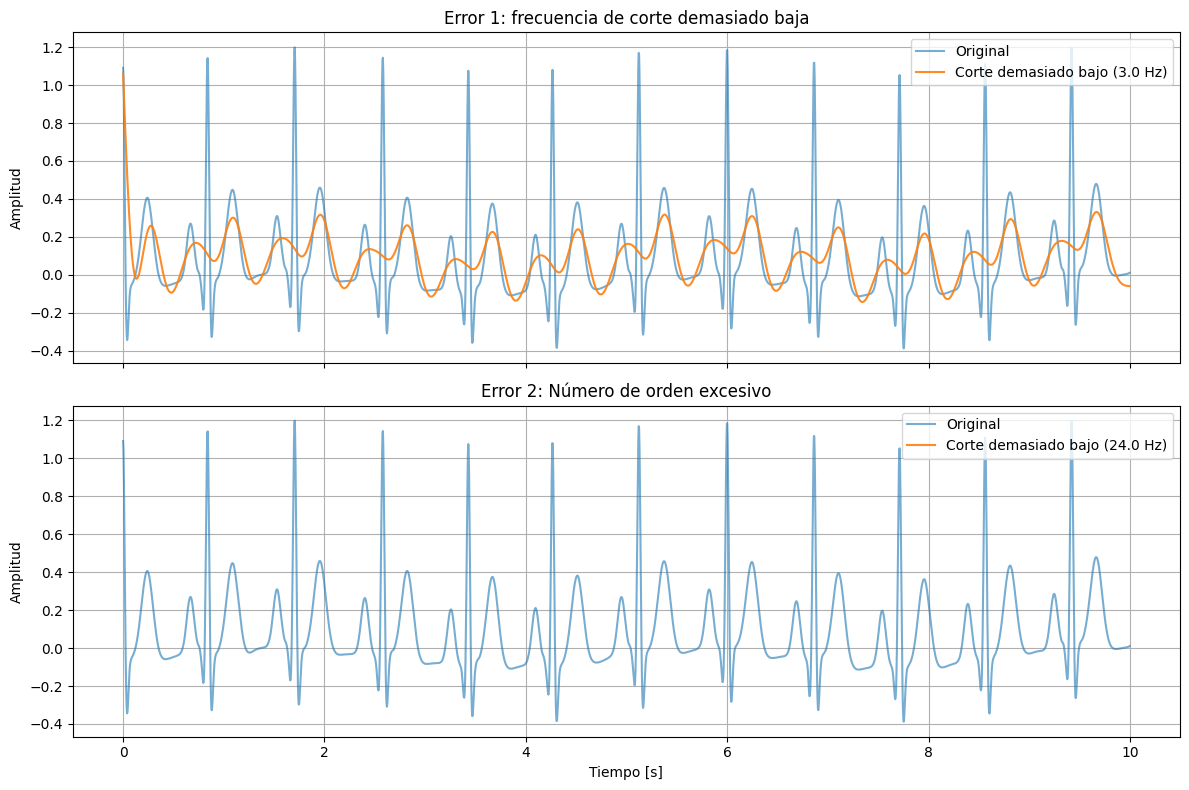

MSE con frecuencia de corte demasiado bajo (3.0 Hz): 4.254e-02
MSE con orden excesivo (24.0 Hz): nan


In [66]:
# Respuesta - Demostración de dos errores de diseño

# Error 1: frecuencia de corte demasiado baja (distorsiona el QRS)
cutoff_low1 = 3.0
sos_low = signal.butter(N=4, Wn=cutoff_low1, btype="lowpass", fs=fs, output="sos")
ecg_bad_low1 = signal.sosfiltfilt(sos_low, ecg_contaminated)

# Error 2: filtrado sin compensar la fase (sosfilt en vez de sosfiltfilt)
# esto sí introduce desplazamiento de fase / retardo de grupo
cutoff_low2 = 24.0
sos_low2 = signal.butter(N=500, Wn=cutoff_low2, btype="lowpass", fs=fs, output="sos")
ecg_bad_low2 = signal.sosfiltfilt(sos_low2, ecg_contaminated)

fig, axs = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axs[0].plot(t, ecg_clean, label="Original", alpha=0.6)
axs[0].plot(t, ecg_bad_low1, label=f"Corte demasiado bajo ({cutoff_low1} Hz)", alpha=0.9)
axs[0].set_title("Error 1: frecuencia de corte demasiado baja")
axs[0].set_ylabel("Amplitud")
axs[0].legend()
axs[0].grid(True)

axs[1].plot(t, ecg_clean, label="Original", alpha=0.6)
axs[1].plot(t, ecg_bad_low2, label=f"Corte demasiado bajo ({cutoff_low2} Hz)", alpha=0.9)
axs[1].set_title("Error 2: Número de orden excesivo")
axs[1].set_xlabel("Tiempo [s]")
axs[1].set_ylabel("Amplitud")
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()

mse_low1 = np.mean((ecg_bad_low1 - ecg_clean) ** 2)
print(f"MSE con frecuencia de corte demasiado bajo ({cutoff_low1} Hz): {mse_low1:.3e}")
mse_low1 = np.mean((ecg_bad_low2 - ecg_clean) ** 2)
print(f"MSE con orden excesivo ({cutoff_low2} Hz): {mse_low1:.3e}")

### Respuesta — Análisis de los errores de diseño

**Error 1: frecuencia de corte demasiado baja (5 Hz)**
1. *Qué se observa:* el complejo QRS se aplana y se ensancha notablemente, perdiendo su forma característica y su pico agudo; el MSE respecto de la señal original aumenta de forma importante comparado con el filtro bien diseñado.
2. *Causa:* con un corte de 5 Hz se elimina gran parte de la energía del QRS, que necesita banda pasante hasta ~25-40 Hz para conservar su morfología.
3. *Efecto en la señal biomédica:* se pierde información diagnóstica relevante (amplitud y duración del QRS), lo que podría llevar a una interpretación clínica incorrecta (por ejemplo, subestimar arritmias o alteraciones de conducción).
4. *Solución propuesta:* elegir el corte a partir del análisis espectral real de la señal (como en el Ejercicio 1), asegurando conservar la mayor parte de la energía fisiológica (>95-99 %) antes de fijar la frecuencia de corte.

**Nuestro análisis**
**Error 1: frecuencia de corte demasiado baja (3Hz)**
1. Qué se observa: observando la gráfica del error se puede que se pierde el complejo QRS y solo se llega a diferenciar los componentes P y T, además que se observa que tiene un MSE grande lo que significa que la señal filtrada se diferencia mucho de la original.
2. Causa: Se debe a que se puso un filtro demasiado bajo, entonces se eliminando señales, como el complejo QRS que por lo general este se encuentran a señales un poco más altas
3. Efecto en la señal biomnédica: se pierde por completo el complejo QRS, en la imagen se puede corroborar donde solo se observa componente P y T
4. Solución propuesta: elegir una frecuencia de corte mayor, con el que no atenue componente importantes de nuestras señales, lo recomendable sería 40Hz

**Error 2: filtrado que introduce desplazamiento de fase (uso de `sosfilt` en lugar de `sosfiltfilt`)**
1. *Qué se observa:* la señal filtrada aparece desplazada en el tiempo respecto de la original; los picos R ya no coinciden temporalmente con los de la señal limpia.
2. *Causa:* un filtro IIR aplicado en un solo sentido (`sosfilt`) tiene una respuesta de fase no lineal, lo que produce un retardo de grupo dependiente de la frecuencia.
3. *Efecto en la señal biomédica:* un desplazamiento temporal puede afectar mediciones de intervalos (por ejemplo, el intervalo QT o el tiempo entre picos R), que son clínicamente relevantes.
4. *Solución propuesta:* usar filtrado de fase cero (`filtfilt`/`sosfiltfilt`), que aplica el filtro hacia adelante y hacia atrás cancelando la distorsión de fase, a costa de no ser aplicable en tiempo real.

**Error 2: orden excesivo (N=500 o más de 1000)**
1. Qué se observa: con el de orden 500 la señal mantiene su morfología pero el tiempo de procesamiento es mayor, visualmente no parece cambiar mucho, pero demora 1 segundo más; con el de orden 1000 ya no corre el código pues la complejidad es demasiado complejo
2. Causa: el orden excesivo elegido, eso aumenta la complejidad del filtro y también la cantidad de cálculos necesarios para procesar la señal y eso aumenta un costo computacional mayor
3. Efecto en la señal biomédica: no afectaría casi nada en la señal, pues al aumentar el orden solo harías que el filtro sea más selectivo, y en este caso no es necesario
4. Solución propuesta: disminuir el orden, pues en este caso no es necesario, con un filtro 4 o hasta de 6 es suficiente, porque colocar un orden mayor sería un aumento de costo computacional innecesario

# Preguntas integradoras

1. ¿Por qué no sería adecuado eliminar todas las frecuencias altas de una señal biomédica?
2. ¿Cómo determinaste la frecuencia de corte?
3. ¿Qué información obtuviste de la FFT?
4. ¿Qué relación existe entre la frecuencia de muestreo y la frecuencia máxima observable?
5. ¿Qué ocurre si se utiliza una frecuencia de corte demasiado baja?
6. ¿Qué ocurre si se utiliza una frecuencia de corte demasiado alta?
7. ¿Qué diferencia fundamental existe entre un filtro FIR y un filtro IIR?
8. ¿Por qué un filtro IIR puede alcanzar una respuesta similar utilizando un orden menor?
9. ¿Qué relación existe entre polos, ceros y respuesta en frecuencia?
10. ¿Por qué la Transformada Z es útil para estudiar filtros digitales?
11. ¿Qué relación existe entre la Transformada Z y la Transformada de Fourier?
12. ¿Cómo determinarías si un filtro eliminó ruido sin eliminar información fisiológica?

### Respuesta — Preguntas integradoras



1. Porque no todas las señales altas corresponden a ruido, algunas forman parte de los complejos QRS y podrías atenuarlas o reducir su amplitud
2. Se determina con la ayuda del análisis de la FFT y experimentando valores, como diferentes frecuencias de corte y teniendo en cuenta también el orden, y posteriormente validandolas con inspección visual, el MSE y el SNR
3. Las componente frecuenciales presentes en la señal y sus magnitudes
4. Se relacionan mediante el teorema de Nyquist, donde si tu frecuencia máxima es "x", entonces tu frecuencia de muestreo tiene que ser mayor o igual a "2x"
5. El filtro podría eliminar ruido y componentes fisiológicos importantes de la señal, como sucedió en el error 1 que propusimos, se atenúa el complejo QRS
6. Se deja pasar mayor cantidad de componentes y entre ellas podría estar el ruido
7. La diferencia fundamental es que el filtro IIR utiliza retroalimentación
8. Debido a utiliza retroalimentación, pues eso le permite obtener una respuesta en frecuencia mása selectiva con menos coeficientes
9. Los polos y ceros están dentro de la función de transferencia y son los encargados de determinar el comportamiento en frecuencia (ceros->atenuación; polos->forma de la respuesta y selectividad)
10. Porque nos permite poder representar matemáticamente un sistema digital gracias a su función de transferencia, y analizarlos mediante sus polos, ceros y respuesta en frecuencia
11. La transformada Z nos permite analizar en el dominio complejo, mientras que la transformada de Fourier nos permite analizar su comportamiento en frecuencia
12. Analizando la gráfica en el dominio temporal (que tanto se asemeja con la señal original), usando la FFT para verificar si hay algún componente frecuencial no deseado, validando mediante el MSE (valor muy bajo) y SNR (valor alto), etc.

# Entregable

Guardar el notebook como:

```text
Apellido_Nombre_Laboratorio_01.ipynb
```

Debe contener:

1. Código.
2. Gráficas.
3. Resultados.
4. Respuestas a las preguntas.
5. Justificación de las decisiones tomadas.
6. Conclusiones.

**No se evaluará únicamente si el código se ejecuta.** Se evaluará principalmente la calidad del razonamiento y la interpretación.

# Rúbrica de evaluación — 20 puntos

| Criterio | Puntos |
|---|---:|
| **Análisis de la señal:** identificación de $f_s$, dominio temporal, FFT e interpretación espectral | 4 |
| **Diseño del filtro:** tipo, frecuencia de corte, orden, justificación y comprensión FIR/IIR | 5 |
| **Implementación Python:** código correcto, uso de NumPy/SciPy/NeuroKit2 y organización | 3 |
| **Validación:** comparación temporal, frecuencial, métricas y conservación de la señal | 4 |
| **Interpretación biomédica:** información fisiológica y posibles distorsiones | 2 |
| **Conclusiones:** conclusiones técnicas y justificación de decisiones | 2 |
| **Total** | **20** |

# Conclusión

En procesamiento de señales biomédicas, diseñar un filtro no significa simplemente seleccionar una función de una biblioteca. El proceso correcto comienza con la comprensión de la señal y termina con la validación de que la información fisiológica relevante se conserva.

La actividad conecta:

**Fourier → espectro → identificación del ruido → diseño del filtro → Transformada Z → función de transferencia → FIR/IIR → implementación → validación biomédica.**

### Reflexión final

Completa:

> "Primero inspecciono la señal, luego ____________________, después ____________________, finalmente ____________________."

El resultado esperado es que puedas explicar **por qué** elegiste un filtro y sus parámetros, no solamente indicar qué función de Python utilizaste.

### Respuesta — Reflexión final

> "Primero inspecciono la señal, luego **la analizo en el dominio temporal y frecuencial (FFT) para identificar el contenido fisiológico y el posible ruido**, después **diseño y aplico el filtro (FIR o IIR) con parámetros justificados a partir de ese análisis**, finalmente **valido el resultado comparando señales y espectros, calculando métricas cuantitativas (MSE, RMSE, SNR) y verificando que la información fisiológica relevante (morfología del QRS, frecuencia cardíaca) se conserve**."

En síntesis: el flujo Fourier → espectro → identificación del ruido → diseño del filtro → Transformada Z → función de transferencia → FIR/IIR → implementación → validación biomédica no es una secuencia mecánica de funciones de Python, sino una cadena de decisiones justificadas en las características reales de la señal.

### Nuestra respuesta — Reflexión final
En este laboratorio se realizó procesamiento digital de una señal de ECG, iniciando con la caracterización de la señal en el dominio del tiempo y frecuencia.
La transformada de Fourier ayudó a identificar nuestras principales componentes frecuenciales y frecuencias pertenecientes a ruido. También se diseñaron y se comparó 2 tipos de filtro, FIR y IIR, analizando sus características, orden, respuesta en frecuencia, costo computacional entre otros.
Se realizó el ejercició de filtrar una señal con ruido, que mediante la FFT se pudo detectar a que frecuencia se encontraba para que posteriormente diseñar un filtro que pueda atenuar dicho filtro sin alterar o modificar nuestra señal, para ello se tuvo que hacer inspección visual de la señal original y filtrada en el dominio del tiempo, para ver si se diferenciaban, además de usar también el MSE y SNR.